In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load
df = pd.read_csv('creditcard.csv')

# first look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Cell 2: Missing Values & Data Types

print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Any missing values? ===")
print("Total missing:", df.isnull().sum().sum())

=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [3]:
# Cell 3: Class Distribution

print("=== Class Distribution ===")
print(df['Class'].value_counts())

print("\n=== Percentage ===")
print(df['Class'].value_counts(normalize=True) * 100)

=== Class Distribution ===
Class
0    284315
1       492
Name: count, dtype: int64

=== Percentage ===
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
# Cell 4: Statistical Summary

print("=== Amount Statistics ===")
print(df['Amount'].describe())

print("\n=== Time Statistics ===")
print(df['Time'].describe())

=== Amount Statistics ===
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

=== Time Statistics ===
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


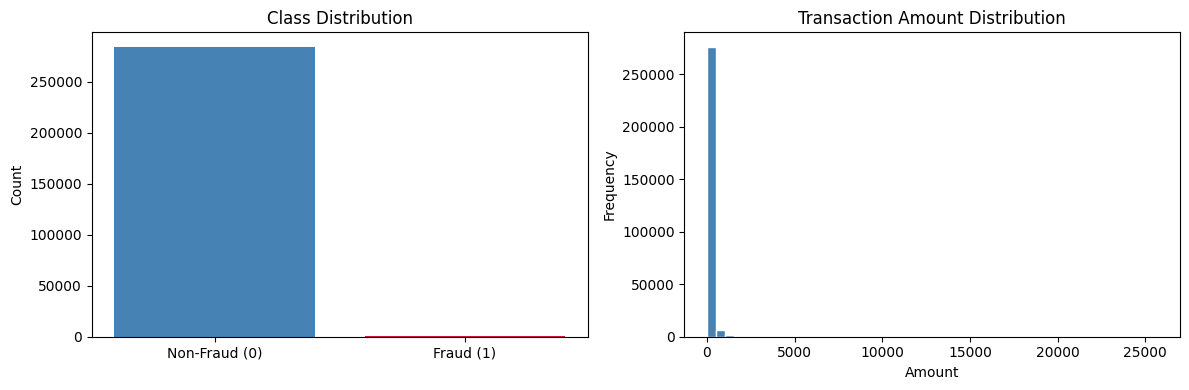

In [5]:
# Cell 5: Visualizations


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], 
            df['Class'].value_counts().values, 
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Amount distribution
axes[1].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

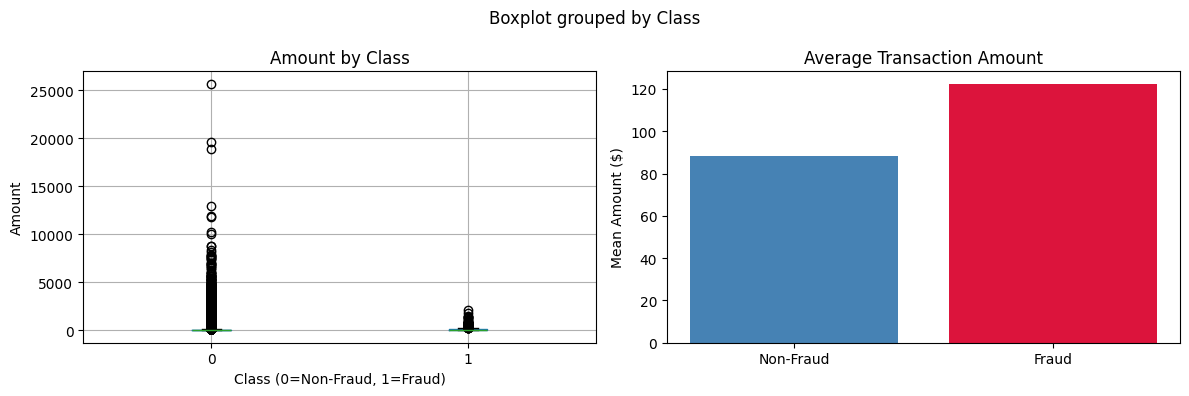


Mean Amount - Non-Fraud: 88.29
Mean Amount - Fraud: 122.21


In [6]:
# Cell 6: Fraud vs Non-Fraud Amount Comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
df.boxplot(column='Amount', by='Class', ax=axes[0])
axes[0].set_title('Amount by Class')
axes[0].set_xlabel('Class (0=Non-Fraud, 1=Fraud)')
axes[0].set_ylabel('Amount')

# Mean amount comparison
mean_amounts = df.groupby('Class')['Amount'].mean()
axes[1].bar(['Non-Fraud', 'Fraud'], mean_amounts.values, color=['steelblue', 'crimson'])
axes[1].set_title('Average Transaction Amount')
axes[1].set_ylabel('Mean Amount ($)')

plt.tight_layout()
plt.show()

print("\nMean Amount - Non-Fraud:", round(df[df['Class']==0]['Amount'].mean(), 2))
print("Mean Amount - Fraud:", round(df[df['Class']==1]['Amount'].mean(), 2))

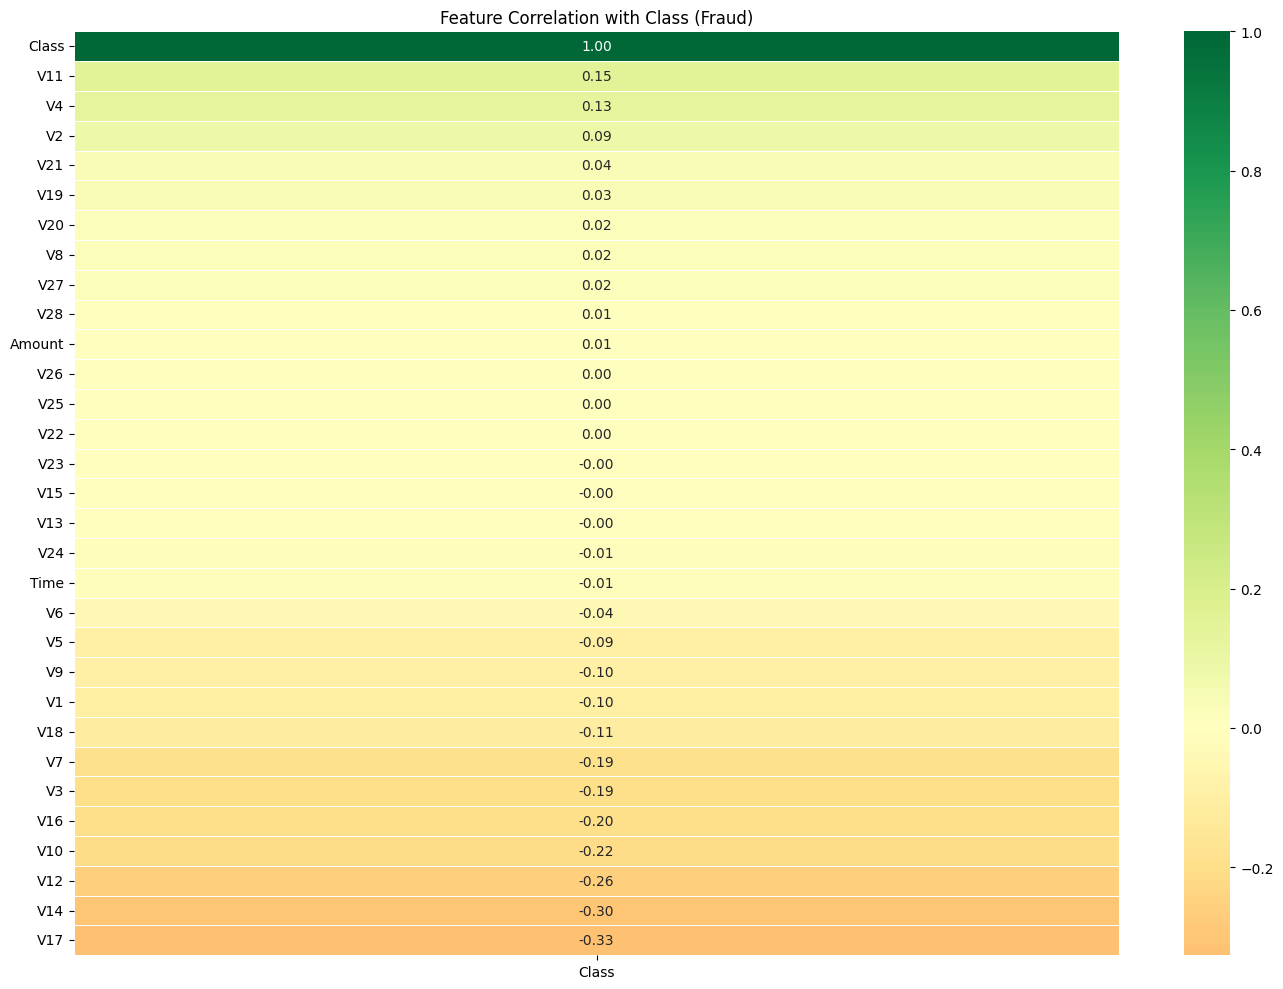

In [7]:
# Cell 7: Correlation Heatmap

plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values('Class', ascending=False), 
            annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, linewidths=0.5)
plt.title('Feature Correlation with Class (Fraud)')
plt.tight_layout()
plt.show()

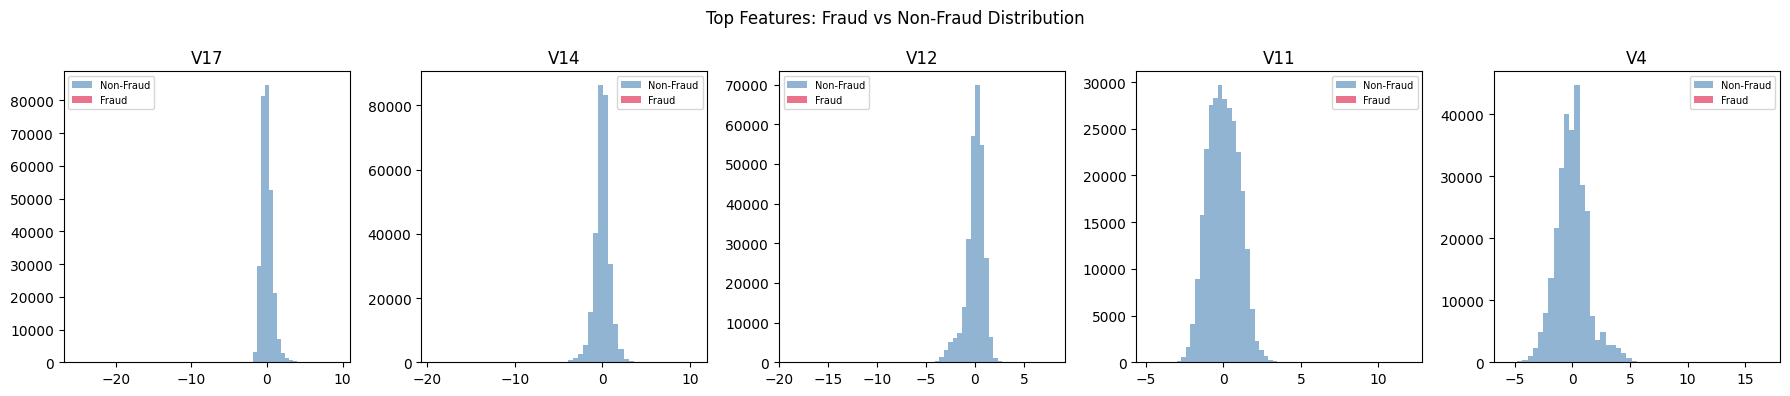

In [8]:
# Cell 8: Top Features Distribution (Fraud vs Non-Fraud)
import matplotlib.pyplot as plt
top_features = ['V17', 'V14', 'V12', 'V11', 'V4']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature], bins=50, alpha=0.6, 
                 color='steelblue', label='Non-Fraud')
    axes[i].hist(df[df['Class']==1][feature], bins=50, alpha=0.6, 
                 color='crimson', label='Fraud')
    axes[i].set_title(feature)
    axes[i].legend(fontsize=7)

plt.suptitle('Top Features: Fraud vs Non-Fraud Distribution')

plt.tight_layout()
plt.show()

In [9]:
# Cell 9: Feature Scaling (Preprocessing)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df_clean = df.drop(['Amount', 'Time'], axis=1)

print("Shape after scaling:", df_clean.shape)
print("\nNew columns added: Amount_Scaled, Time_Scaled")
print(df_clean[['Amount_Scaled', 'Time_Scaled']].describe().round(2))

Shape after scaling: (284807, 31)

New columns added: Amount_Scaled, Time_Scaled
       Amount_Scaled  Time_Scaled
count      284807.00    284807.00
mean           -0.00        -0.00
std             1.00         1.00
min            -0.35        -2.00
25%            -0.33        -0.86
50%            -0.27        -0.21
75%            -0.04         0.94
max           102.36         1.64


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Train-test split
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}")

Train size: (227845, 30), Test size: (56962, 30)
Fraud in train: 394 | Fraud in test: 98


LOGISTIC REGRESSION - Classification Report
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9722


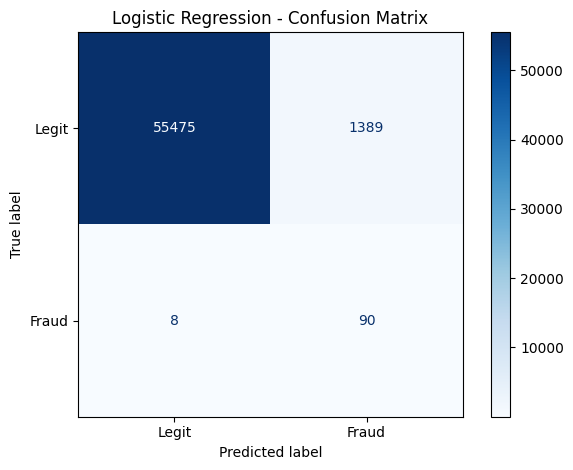

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("LOGISTIC REGRESSION - Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

RANDOM FOREST - Classification Report
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9581


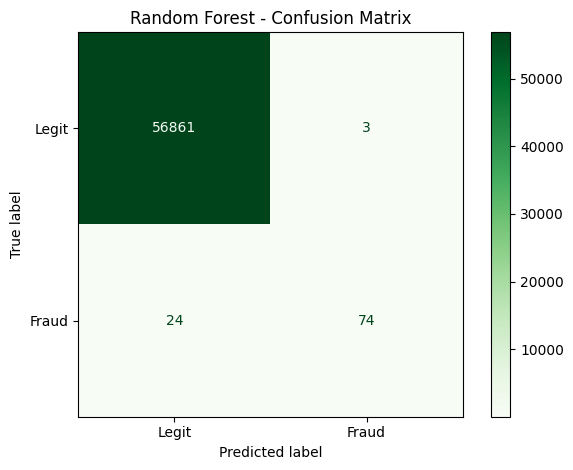

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("RANDOM FOREST - Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Legit', 'Fraud'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

XGBOOST - Classification Report
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9645


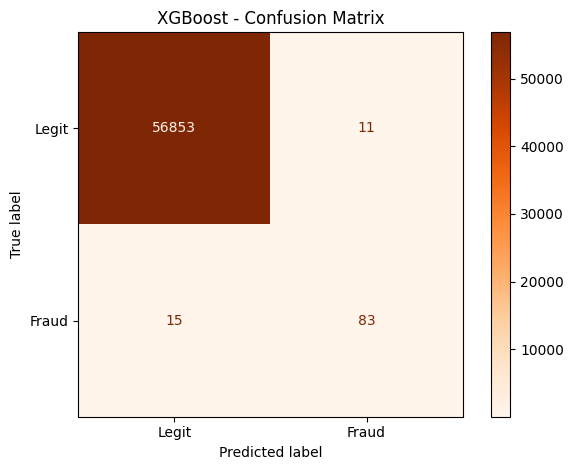

In [13]:
from xgboost import XGBClassifier

# Train
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=577, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("XGBOOST - Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Legit', 'Fraud'])
disp_xgb.plot(cmap='Oranges')
plt.title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.show()

              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression       0.06    0.92      0.11   0.9722
      Random Forest       0.96    0.76      0.85   0.9581
            XGBoost       0.88    0.85      0.86   0.9645


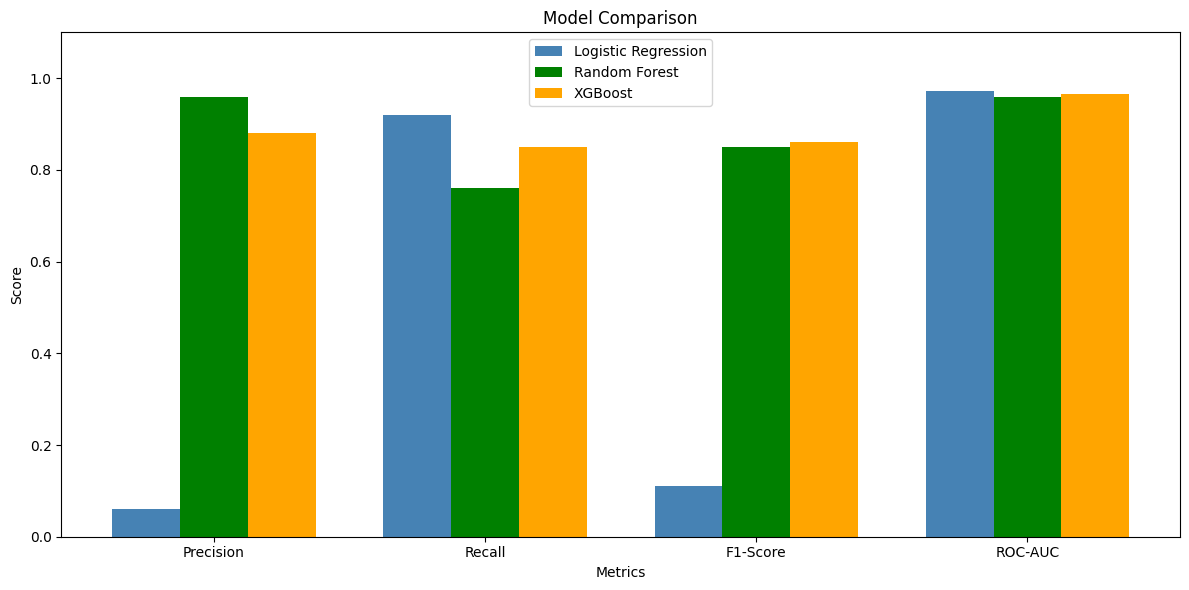

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [0.06, 0.96, 0.88],
    'Recall': [0.92, 0.76, 0.85],
    'F1-Score': [0.11, 0.85, 0.86],
    'ROC-AUC': [0.9722, 0.9581, 0.9645]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Bar chart
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, df_results.loc[0, metrics], width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x, df_results.loc[1, metrics], width, label='Random Forest', color='green')
bars3 = ax.bar(x + width, df_results.loc[2, metrics], width, label='XGBoost', color='orange')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

Before SMOTE - Fraud: 394 | Legit: 227451
After SMOTE  - Fraud: 22745 | Legit: 227451

XGBOOST + SMOTE - Classification Report
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9779


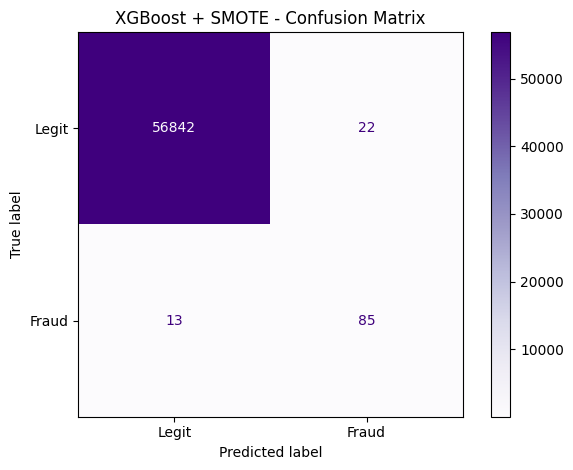

In [15]:
from imblearn.over_sampling import SMOTE

# SMOTE lagao
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Fraud: {y_train.sum()} | Legit: {(y_train==0).sum()}")
print(f"After SMOTE  - Fraud: {y_train_sm.sum()} | Legit: {(y_train_sm==0).sum()}")

# XGBoost SMOTE ke saath train karo
xgb_smote = XGBClassifier(n_estimators=100, scale_pos_weight=1, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_sm, y_train_sm)

# Predict
y_pred_smote = xgb_smote.predict(X_test)
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]

# Evaluation
print("\n" + "=" * 50)
print("XGBOOST + SMOTE - Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_smote, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_smote):.4f}")

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['Legit', 'Fraud'])
disp_smote.plot(cmap='Purples')
plt.title('XGBoost + SMOTE - Confusion Matrix')
plt.tight_layout()
plt.show()

FINAL MODEL COMPARISON
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression       0.06    0.92      0.11   0.9722
      Random Forest       0.96    0.76      0.85   0.9581
            XGBoost       0.88    0.85      0.86   0.9645
    XGBoost + SMOTE       0.79    0.87      0.83   0.9779

✅ Best Model: XGBoost + SMOTE (Highest ROC-AUC: 0.9779)
✅ Best Recall: 87% (85 out of 98 fraud cases detected)
✅ False Alarms: Only 22 legitimate transactions flagged


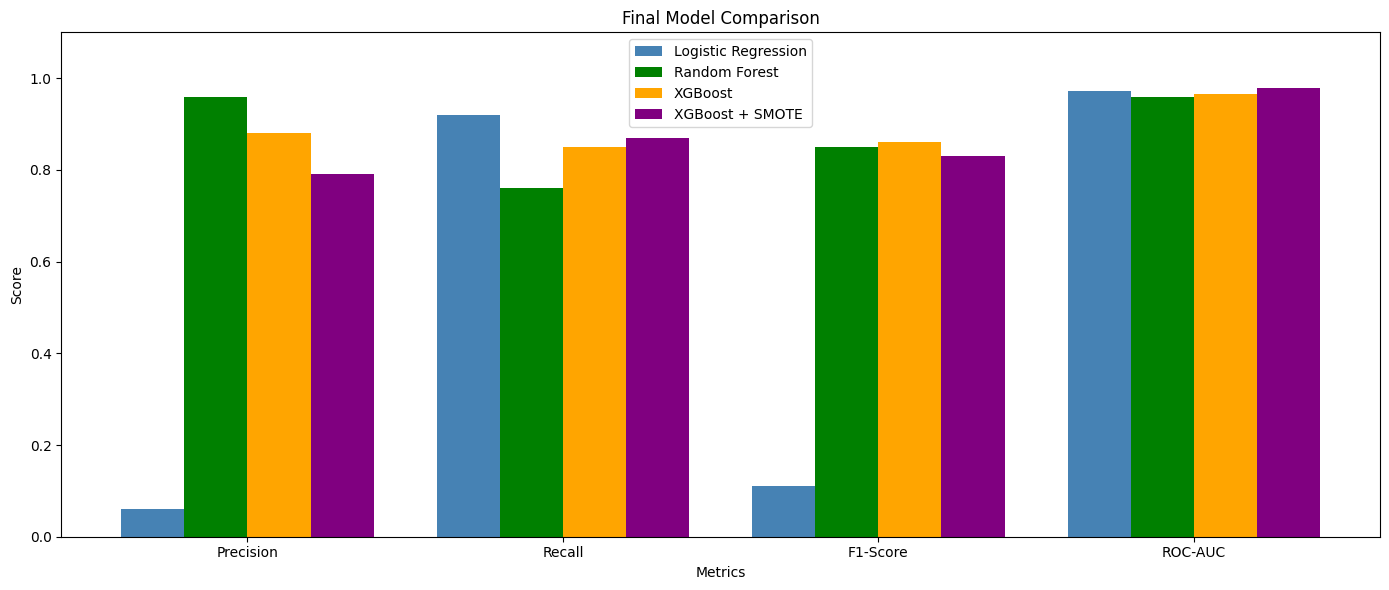

In [16]:
# Final Comparison Table
final_results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'XGBoost + SMOTE'],
    'Precision': [0.06, 0.96, 0.88, 0.79],
    'Recall': [0.92, 0.76, 0.85, 0.87],
    'F1-Score': [0.11, 0.85, 0.86, 0.83],
    'ROC-AUC': [0.9722, 0.9581, 0.9645, 0.9779]
}

df_final = pd.DataFrame(final_results)
print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)
print(df_final.to_string(index=False))
print("=" * 65)
print("\n✅ Best Model: XGBoost + SMOTE (Highest ROC-AUC: 0.9779)")
print("✅ Best Recall: 87% (85 out of 98 fraud cases detected)")
print("✅ False Alarms: Only 22 legitimate transactions flagged")

# Final Bar Chart
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width*1.5, df_final.loc[0, metrics], width, label='Logistic Regression', color='steelblue')
ax.bar(x - width*0.5, df_final.loc[1, metrics], width, label='Random Forest', color='green')
ax.bar(x + width*0.5, df_final.loc[2, metrics], width, label='XGBoost', color='orange')
ax.bar(x + width*1.5, df_final.loc[3, metrics], width, label='XGBoost + SMOTE', color='purple')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


In [17]:
# Cell 17: Install and import SHAP

import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)

import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("Import successful!")

SHAP version: 0.52.0
Import successful!


In [18]:
# Cell 18: SHAP Analysis - Model Explainability

# Create SHAP explainer on the best model (XGBoost + SMOTE)
explainer = shap.Explainer(xgb_smote)
shap_values = explainer(X_test)

print("SHAP values calculated successfully!")
print(f"Shape: {shap_values.shape}")

SHAP values calculated successfully!
Shape: (56962, 30)


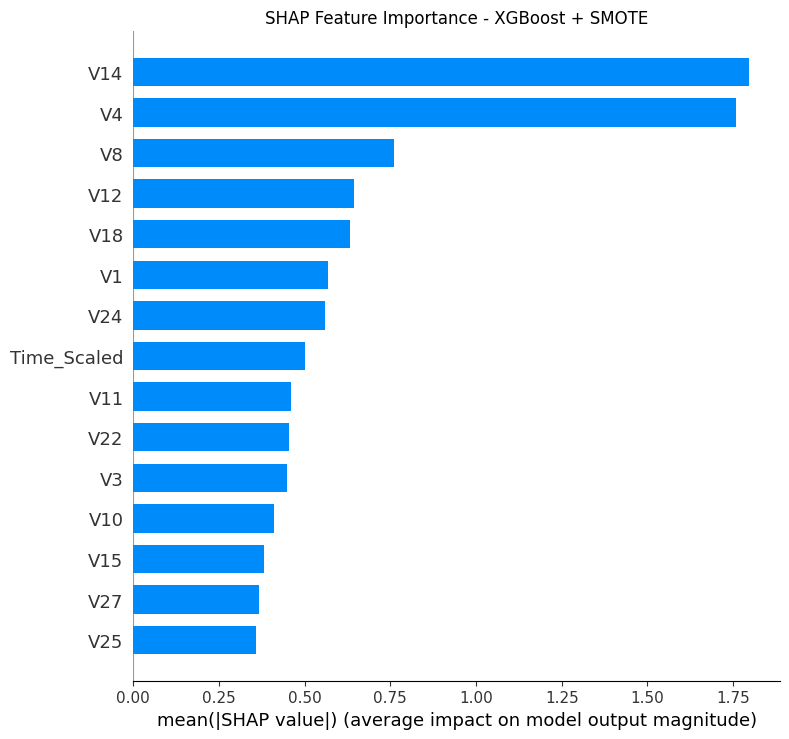

Plot saved: shap_importance.png


In [19]:
# Cell 19: SHAP Feature Importance - Bar Chart

# Bar chart showing which features matter most for fraud detection
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  max_display=15, show=False)
plt.title("SHAP Feature Importance - XGBoost + SMOTE")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: shap_importance.png")

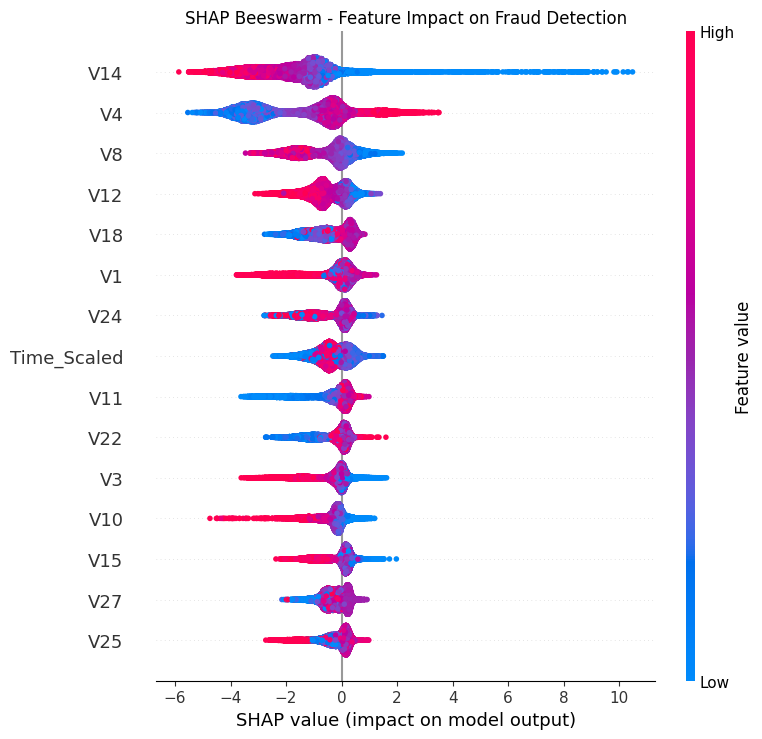

In [20]:
# Cell 20: SHAP Beeswarm Plot - Detailed Feature Impact

# Shows how each feature value pushes prediction toward fraud or not
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  max_display=15, show=False)
plt.title("SHAP Beeswarm - Feature Impact on Fraud Detection")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

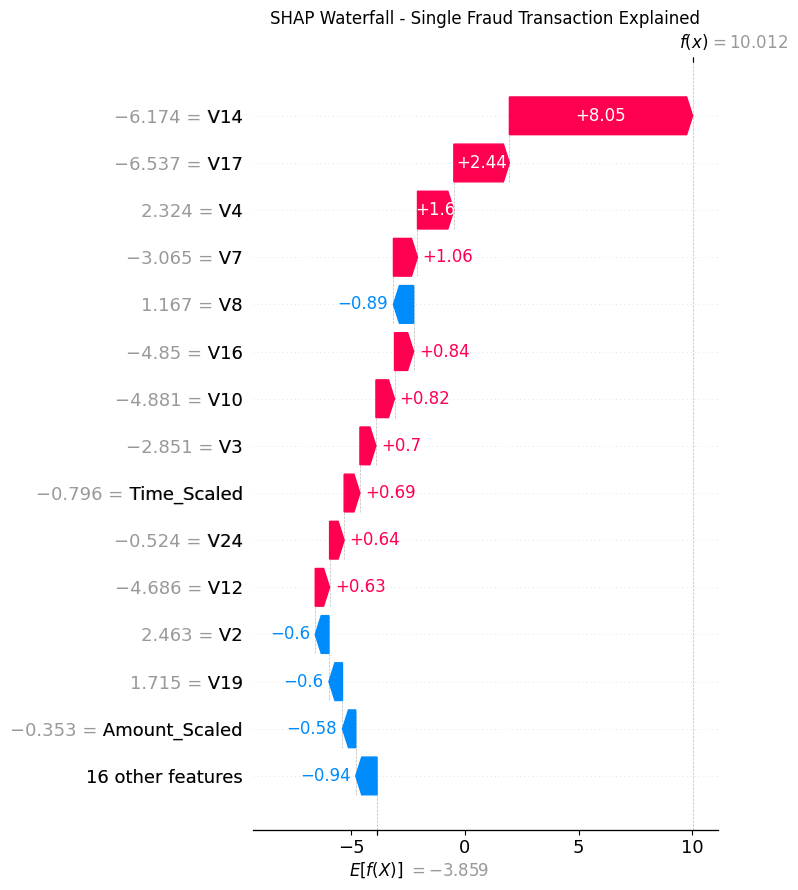

In [21]:
# Cell 21: SHAP Waterfall Plot - Single Transaction Explanation

# Explain one fraud transaction in detail
fraud_indices = X_test[y_test == 1].index
first_fraud = X_test.loc[fraud_indices[0]]
sample_index = X_test.index.get_loc(fraud_indices[0])

plt.figure()
shap.plots.waterfall(shap_values[sample_index], max_display=15, show=False)
plt.title("SHAP Waterfall - Single Fraud Transaction Explained")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Cell 22: Save model to disk

import pickle

with open('xgb_smote_model.pkl', 'wb') as f:
    pickle.dump(xgb_smote, f)

print("Model saved: xgb_smote_model.pkl")

Model saved: xgb_smote_model.pkl
